Slope: 5.031826320287447, Intercept: 2.479253010931925
Line R^2 0.957150335167768 MSE 0.0963659243602124
Polynomial R^2 0.9577417814021872 MSE 0.09503580279888085
Polyfit has a better fit


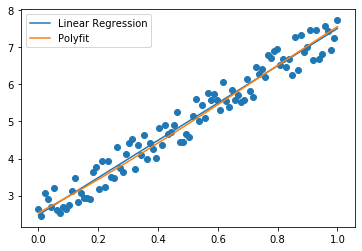

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def r_2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

X = np.linspace(0,1,100)
y = []
rng = np.random.default_rng()

for value in X:
    y.append(value*5+2 + rng.random())
Y = np.array(y)

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

plt.scatter(X,Y)

poly = np.polyfit(X, Y, 3)
y_poly = np.polyval(poly, X)

y1 = m*X+c
plt.plot(X,y1,label="Linear Regression")
plt.plot(X,Y_poly,label="Polyfit")
plt.legend()
print(f"Line R^2 {r_2(Y,y1)} MSE {mse(Y,y1)}")
print(f"Polynomial R^2 {r_2(Y,y_poly)} MSE {mse(Y,y_poly)}")

if r_2(Y,y1) >= r_2(Y,y_poly):
    print(f"Linear regression has a better fit")
else:
    print(f"Polyfit has a better fit")

In [32]:
#Base case of degree 1
poly = np.polyfit(X, Y, 1)
y_poly = np.polyval(poly, X)
prevMse = mse(Y,y_poly)
prevR_2 = r_2(Y,y_poly)

MSE = [prevMse]
R_2 = [prevR_2]

overfitDegree = -1

#Since x takes small steps we can approximate the noise variance by calculating the variance of 
#the set defined by difference between Y[i+1] - Y[i] for all i = 0,1..n-1 where n = len(Y)
#sqrt 2 accounts for doubling the variance. This is used to evalute for underfitting / overfitting
noise_std = np.std(np.diff(Y)) / np.sqrt(2)

#increasing degree until overfit
for degree in range(2,80):
    poly = np.polyfit(X, Y, degree)
    y_poly = np.polyval(poly, X)
    
    currentMse = mse(Y,y_poly)
    currentR_2 = r_2(Y,y_poly)
    
    print(f"Degree {degree} MSE={currentMse} R_2={currentR_2}")
    
    MSE.append(currentMse)
    R_2.append(currentR_2)
    
    #This checks if the max effect of the highest degree is less than the effect of noise
    #if it is then model is overfitting because the new term is only accounting for noise
    if (abs(poly[0]) * (X.max() - X.min())**degree) <= noise_std:
        print(f"blantantly overfits at degree {degree}")
        overfitDegree = degree
        print(poly)
        break
    prevMse = currentMse
    prevR_2 = currentR_2

underfitDegree = -1

#Starting at a high degree bc starting at degree 2 is odd
for degree in range(10, -1, -1):
    poly = np.polyfit(X, Y, degree)
    y_poly = np.polyval(poly, X)
    
    currentMse = mse(Y, y_poly)
    currentR_2 = r_2(Y, y_poly)
    
    print(f"Degree {degree} MSE={currentMse} R_2={currentR_2}")

    #Underfits if its error is greater than the noise
    if currentMse > 2*noise_std:
        print(f"blatantly underfits at degree {degree}")
        underfitDegree = degree
        break

    underfitDegree = degree
    prevMse = currentMse

print(f"\nOverfit degree:  {overfitDegree}")
print(f"Underfit degree: {underfitDegree}")

Degree 2 MSE=0.096320 R_2=0.957171
blantantly overfits at degree 2
[-0.08872467  5.12055099  2.46461493]
Degree 10 MSE=0.088921 R_2=0.960461
Degree 9 MSE=0.089559 R_2=0.960177
Degree 8 MSE=0.091699 R_2=0.959226
Degree 7 MSE=0.091763 R_2=0.959197
Degree 6 MSE=0.092146 R_2=0.959027
Degree 5 MSE=0.093556 R_2=0.958400
Degree 4 MSE=0.094978 R_2=0.957768
Degree 3 MSE=0.095036 R_2=0.957742
Degree 2 MSE=0.096320 R_2=0.957171
Degree 1 MSE=0.096366 R_2=0.957150
Degree 0 MSE=2.248931 R_2=0.000000
blatantly underfits at degree 0

Overfit degree:  2
Underfit degree: 0


In [46]:
V = np.vander(X)
coeffs = np.linalg.lstsq(V, Y, rcond=None)
y_vander = V @ coeffs[0]

print(f"Vandermonde MSE={mse(Y, y_vander)} R_2={r_2(Y, y_vander)}")

Vandermonde MSE=0.06871570014622932 R_2=0.9694451670595525
